 # Predicting FIFA World Cup Match Outcomes Using Supervised Classification
## For this project I'll use Soccer Dataset for the FIFA WorldCup Data. Data can be found at https://www.football-data.co.uk/
## Overview of the project
This project tries to predict world cup results from previous FIFA World Cups (2022,2018,2014) and from the 2026 FIFA World Cup qualifyers.
Because Soccer Games can end in draws, the prediction is framed as a three-class classification.
- Home Win
- Draw
- Away Win

#### The following documentation of the dataset was created with AI in order to have a description of the data.


## Soccer Dataset Data Dictionary

### 1. General Match Information
| Column | Description |
| :--- | :--- |
| `Competition` | Name of the league or tournament |
| `Home` | Home team name |
| `Away` | Away team name |
| `Date` | Match date |
| `Time` | Kick-off time |
| `Type` | Stage or fixture type (e.g., Group Stage, Knockout, Qualifier) |
| `Finished` | Indicates if the match completed normally |

### 2. Goals & Scores Breakdown
| Column | Description |
| :--- | :--- |
| `HG` / `HGFT` | Home Goals Full Time (Final score) |
| `AG` / `AGFT` | Away Goals Full Time (Final score) |
| `HG1st` / `AG1st` | Home / Away goals scored in the 1st half |
| `HG2nd` / `AG2nd` | Home / Away goals scored in the 2nd half |
| `HGET` / `AGET` | Home / Away goals scored during Extra Time (Knockouts) |
| `HGP` | Home Goals in Penalty Shootout |
| `HGP.1` | Away Goals in Penalty Shootout (*Duplicate `HGP` column auto-renamed by pandas*) |

### 3. In-Game Match Statistics
| Column | Description |
| :--- | :--- |
| `HS` / `AS` | Home / Away total Shots |
| `HST` / `AST` | Home / Away Shots on Target |
| `HF` / `AF` | Home / Away Fouls committed |
| `HC` / `AC` | Home / Away Corners taken |
| `HY` / `AY` | Home / Away Yellow Cards |
| `HR` / `AR` | Home / Away Red Cards |

### 4. Advanced Analytics
| Column | Description |
| :--- | :--- |
| `HxG` | **Home Expected Goals** (Quality/probability of chances created by home team) |
| `AxG` | **Away Expected Goals** (Quality/probability of chances created by away team) |

### 5. Betting Odds (1X2 Market)
> **Note:** `H` = Home Win, `D` = Draw, `A` = Away Win

| Column | Description |
| :--- | :--- |
| `bet365-H` / `D` / `A` | Closing odds from Bet365 |
| `Betfair_Exch-H` / `D` / `A` | Closing exchange odds from Betfair |
| `Pinny-H` / `D` / `A` | Closing odds from Pinnacle (Sharp bookmaker) |
| `H-Max` / `D-Max` / `A-Max` <br> (`H_Max` / `D_Max` / `A_Max`) | Maximum odds available across all surveyed bookmakers |
| `H-Avg` / `D-Avg` / `A-Avg` <br> (`H_Avg` / `D_Avg` / `A_Avg`) | Average odds available across all surveyed bookmakers |

In [1]:
import pandas as pd
from IPython.display import display as show_table

PATH = "datasets/WorldCup2026.xlsx"
df_2026 = pd.read_excel(PATH, sheet_name="WorldCup2026")
df_QF = pd.read_excel(PATH, sheet_name="WorldCup2026Qualifiers")
df_2022 = pd.read_excel(PATH, sheet_name="WorldCup2022")
df_2018 = pd.read_excel(PATH, sheet_name="WorldCup2018")
df_2014 = pd.read_excel(PATH, sheet_name="WorldCup2014")

df_QF['Competition']= 'World Cup 2026 Qualifiers'
df_QF = df_QF.rename(columns={
    'HG': 'HGFT',
    'AG': 'AGFT',
    'H_Avg': 'H-Avg',
    'D_Avg': 'D-Avg',
    'A_Avg': 'A-Avg'
})

dev_df = pd.concat(
    [df_QF, df_2022, df_2018, df_2014],
    ignore_index=True
)

test_2026 = df_2026.copy()
dev_df.Competition.value_counts()


Competition
World Cup 2026 Qualifiers    889
World Cup 2022                64
World Cup 2018                64
World Cup 2014                64
Name: count, dtype: int64

In [2]:
test_2026.head()

,Competition,Home,Away,Date,Time,HGFT,AGFT,HG1st,AG1st,HG2nd,...,bet365-A,Betfair_Exch-H,Betfair_Exch-D,Betfair_Exch-A,H-Max,D-Max,A-Max,H-Avg,D-Avg,A-Avg
0,World Cup 2026,Mexico,South Africa,2026-06-11,20:00:00,2,0,1,0,1,...,8.50,1.45,4.60,9.60,1.44,4.50,9.10,1.41,4.33,8.26
1,World Cup 2026,South Korea,Czech Republic,2026-06-12,03:00:00,2,1,0,0,2,...,3.00,2.64,3.20,3.15,2.66,3.20,3.05,2.54,3.06,2.93
2,World Cup 2026,Canada,Bosnia & Herzegovina,2026-06-12,20:00:00,1,1,0,1,1,...,4.75,1.89,3.65,4.90,1.85,3.55,4.80,1.82,3.45,4.52
3,World Cup 2026,USA,Paraguay,2026-06-13,02:00:00,4,1,3,0,1,...,3.80,2.14,3.30,4.30,2.07,3.40,4.00,2.03,3.21,3.84
4,World Cup 2026,Qatar,Switzerland,2026-06-13,20:00:00,1,1,0,1,1,...,1.18,18.50,8.20,1.20,17.00,7.50,1.22,14.57,6.88,1.19


In [3]:
dev_df.columns

Index(['Date', 'Home', 'Away', 'HGFT', 'AGFT', 'H_Max', 'D_Max', 'A_Max',
       'H-Avg', 'D-Avg', 'A-Avg', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC',
       'AC', 'HY', 'AY', 'HR', 'AR', 'HxG', 'AxG', 'Competition', 'Time',
       'HG1st', 'AG1st', 'HG2nd', 'AG2nd', 'HGET', 'AGET', 'HGP', 'HGP.1',
       'Finished', 'bet365-H', 'bet365-D', 'bet365-A', 'Betfair_Exch-H',
       'Betfair_Exch-D', 'Betfair_Exch-A', 'H-Max', 'D-Max', 'A-Max',
       'Pinny-H', 'Pinny-D', 'Pinny-A'],
      dtype='str')

##### Dataset Description:
- 889 qualifier matches.
- 64 matches from 2014, 2018 and 2022.
- Approximately 1081 matches.
- The 104 Matches from the 2026 World Cup are kept separately.


### IMPORTANT!
Many columns are known AFTER the game, therefore that can lead to **Data Leakage**! such as:
- Goals
- Shots and shots on target
- Expected goals
- Fouls
- Corners
- Cards
- Extra-time and penalty results
These cannot be input features because they reveal information about the result that we try to predict.

#### Information available before kickoff:
- Home
- Away
- H-Avg
- D-Avg
- A-Avg
- bet365-H / D / A
- Betfair_Exch-H / D / A
- Pinny-H / D / A
- H-Max / D-Max / A-Max (H_Max / D_Max / A_Max)
- H-Avg / D-Avg / A-Avg (H_Avg/D_Avg/A_Avg)
- Date or year
- rolling team form from earlier matches
- average goals scored/conceded in previous games,

In [4]:
dev_df

,Date,Home,Away,HGFT,AGFT,H_Max,D_Max,A_Max,H-Avg,D-Avg,...,bet365-A,Betfair_Exch-H,Betfair_Exch-D,Betfair_Exch-A,H-Max,D-Max,A-Max,Pinny-H,Pinny-D,Pinny-A
0,2026-04-01,Iraq,Bolivia,2,1,3.25,3.1,2.5,3.08,2.89,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-31,Bosnia & Herzegovina,Italy,1,1,8,4.35,1.53,6.86,4.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-31,Czech Republic,Denmark,1,1,3.9,3.4,2.1,3.69,3.34,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-31,D.R. Congo,Jamaica,0,0,1.65,3.4,7,1.6,3.26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-31,Kosovo,Turkey,0,1,3.9,3.6,2,3.76,3.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1076,2014-06-14,Colombia,Greece,3,0,NaN,NaN,NaN,1.84,3.26,...,5.50,NaN,NaN,NaN,1.91,3.75,6.0,1.88,3.32,5.32
1077,2014-06-13,Chile,Australia,3,1,NaN,NaN,NaN,1.42,4.4,...,9.00,NaN,NaN,NaN,1.50,4.85,10.5,1.44,4.55,9.44
1078,2014-06-13,Spain,Netherlands,1,5,NaN,NaN,NaN,1.84,3.32,...,5.25,NaN,NaN,NaN,1.91,3.50,5.5,1.85,3.44,5.31
1079,2014-06-13,Mexico,Cameroon,1,0,NaN,NaN,NaN,2.18,3.14,...,3.90,NaN,NaN,NaN,2.25,3.30,4.0,2.22,3.25,3.82


In [5]:
import numpy as np
#Target Variable#
conditions= [
    dev_df['HGFT'] > dev_df['AGFT'],
    dev_df['HGFT'] == dev_df['AGFT']
]
dev_df['Result'] = np.select(
    conditions,
    ['Home Win', 'Draw'],
    default = 'Away Win'
)
conditions= [
    test_2026['HGFT'] > test_2026['AGFT'],
    test_2026['HGFT'] == test_2026['AGFT']
]
test_2026['Result'] = np.select(
    conditions,
    ['Home Win', 'Draw'],
    default = 'Away Win'
)

In [6]:
dev_df['Result'].value_counts()/dev_df['Result'].count()*100

Result
Home Win    45.143386
Away Win    32.839963
Draw        22.016651
Name: count, dtype: float64

The development data contains approximately:
- 45% home wins
- 33% away wins
- 22% draws

As Feature Set I'll start with average simple pre-match odds:

In [7]:
feature_cols= ['H-Avg', 'D-Avg', 'A-Avg']
X = dev_df[feature_cols]
y = dev_df['Result']

X_2026 = test_2026[feature_cols]
y_2026 = test_2026['Result']

In [8]:
test_2026.head()

,Competition,Home,Away,Date,Time,HGFT,AGFT,HG1st,AG1st,HG2nd,...,Betfair_Exch-H,Betfair_Exch-D,Betfair_Exch-A,H-Max,D-Max,A-Max,H-Avg,D-Avg,A-Avg,Result
0,World Cup 2026,Mexico,South Africa,2026-06-11,20:00:00,2,0,1,0,1,...,1.45,4.60,9.60,1.44,4.50,9.10,1.41,4.33,8.26,Home Win
1,World Cup 2026,South Korea,Czech Republic,2026-06-12,03:00:00,2,1,0,0,2,...,2.64,3.20,3.15,2.66,3.20,3.05,2.54,3.06,2.93,Home Win
2,World Cup 2026,Canada,Bosnia & Herzegovina,2026-06-12,20:00:00,1,1,0,1,1,...,1.89,3.65,4.90,1.85,3.55,4.80,1.82,3.45,4.52,Draw
3,World Cup 2026,USA,Paraguay,2026-06-13,02:00:00,4,1,3,0,1,...,2.14,3.30,4.30,2.07,3.40,4.00,2.03,3.21,3.84,Home Win
4,World Cup 2026,Qatar,Switzerland,2026-06-13,20:00:00,1,1,0,1,1,...,18.50,8.20,1.20,17.00,7.50,1.22,14.57,6.88,1.19,Draw


In [9]:
"""
Find Non numeric entries
"""
non_numeric_df = X[pd.to_numeric(X['H-Avg'], errors='coerce').isna()]
print(non_numeric_df)
X.iloc[663]

    H-Avg D-Avg A-Avg
663     -     -     -


H-Avg    -
D-Avg    -
A-Avg    -
Name: 663, dtype: object

In [10]:
X= X.apply(pd.to_numeric, errors='coerce')
print(X.isna().sum())
X=X.fillna(0)
X.iloc[663]


H-Avg    1
D-Avg    1
A-Avg    1
dtype: int64


H-Avg    0.0
D-Avg    0.0
A-Avg    0.0
Name: 663, dtype: float64

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)



## First Model: Logistic Regression

In [12]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipe_lr = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=1000,
                                           random_state=123,
                                           class_weight='balanced'))
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_valid)
test_acc = pipe_lr.score(X_valid, y_valid)
print(f'Test accuracy: {test_acc:.3f}')

Test accuracy: 0.530


In [13]:
y_pred_2026 = pipe_lr.predict(X_2026)
test_acc = pipe_lr.score(X_2026, y_2026)
print(f'Test accuracy: {test_acc:.3f}')



Test accuracy: 0.577


Validation accuracy: 0.5299539170506913
              precision    recall  f1-score   support

    Away Win       0.68      0.58      0.63        71
        Draw       0.23      0.42      0.29        48
    Home Win       0.78      0.55      0.65        98

    accuracy                           0.53       217
   macro avg       0.56      0.52      0.52       217
weighted avg       0.63      0.53      0.56       217



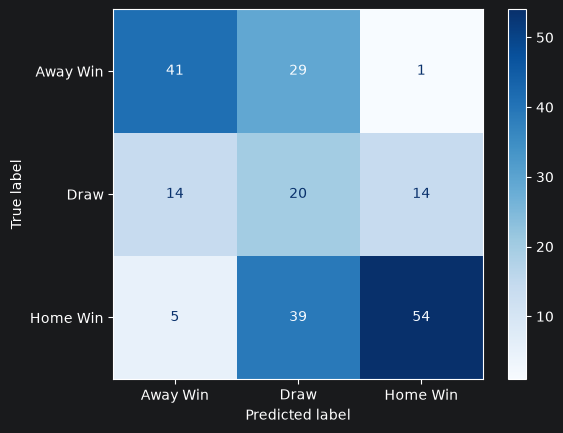

In [14]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

valid_predictions = pipe_lr.predict(X_valid)
lr_f1 = f1_score(y_valid,valid_predictions,average="macro")

print('Validation accuracy:',
      accuracy_score(y_valid, valid_predictions))

print(classification_report(
    y_valid,
    valid_predictions
))

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    valid_predictions,
    cmap='Blues'
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=123
)

forest_model.fit(X_train, y_train)
forest_predictions = forest_model.predict(X_valid)

print('Random Forest validation accuracy:',
      accuracy_score(y_valid, forest_predictions))

Random Forest validation accuracy: 0.5622119815668203


In [16]:
final_model = pipe_lr  # Or forest_model

predictions_2026 = final_model.predict(X_2026)
probabilities_2026 = final_model.predict_proba(X_2026)

prediction_table = test_2026[
    ['Home', 'Away', 'HGFT', 'AGFT']
].copy()

prediction_table['Actual'] = y_2026
prediction_table['Prediction'] = predictions_2026

for index, class_name in enumerate(final_model.classes_):
    prediction_table[f'Probability: {class_name}'] = probabilities_2026[:, index]

prediction_table.head(20)

,Home,Away,HGFT,AGFT,Actual,Prediction,Probability: Away Win,Probability: Draw,Probability: Home Win
0,Mexico,South Africa,2,0,Home Win,Home Win,0.114098,0.393704,0.492198
1,South Korea,Czech Republic,2,1,Home Win,Draw,0.295987,0.436908,0.267105
2,Canada,Bosnia & Herzegovina,1,1,Draw,Draw,0.215960,0.431980,0.352060
3,USA,Paraguay,4,1,Home Win,Draw,0.244582,0.437552,0.317866
4,Qatar,Switzerland,1,1,Draw,Away Win,0.840005,0.145701,0.014294
5,Brazil,Morocco,1,1,Draw,Draw,0.185412,0.425490,0.389098
6,Haiti,Scotland,0,1,Away Win,Away Win,0.488800,0.367555,0.143646
7,Australia,Turkey,2,0,Home Win,Away Win,0.468102,0.386069,0.145829
8,Germany,Curacao,7,1,Home Win,Home Win,0.000014,0.008538,0.991448
9,Netherlands,Japan,2,2,Draw,Draw,0.247229,0.430099,0.322672


Now I'll test with ADALINE One vs All and see accuracy and performance.
In order to improve performance on training, I'll standardize the features first, using SimpleImputer and StandardScaler.

In [17]:
class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
    random_state : int
        Random number generator seed for random weight initialization.

    Attributes
    -----------
    w_ : 1d-array
        Weights after fitting.
    b_ : Scalar
        Bias unit after fitting.
    losses_ : list
      Mean squared error loss function values in each epoch.
    """

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
            Training vectors, where n_examples
            is the number of examples and
            n_features is the number of features.
        y : array-like, shape = [n_examples]
            Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01,
                              size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors ** 2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X))
                        >= 0.5, 1, 0)


In [18]:
class AdalineOVR:
    def __init__(self, eta=0.001, n_iter=200, random_state=123):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models_ = []

        for class_index, class_label in enumerate(self.classes_):
            # Current class becomes 1; every other class becomes 0
            y_binary = np.where(y == class_label, 1, 0)

            model = AdalineGD(
                eta=self.eta,
                n_iter=self.n_iter,
                random_state=self.random_state + class_index
            )

            model.fit(X, y_binary)
            self.models_.append(model)

        return self

    def decision_function(self, X):
        return np.column_stack([
            model.net_input(X)
            for model in self.models_
        ])

    def predict(self, X):
        scores = self.decision_function(X)
        best_model = np.argmax(scores, axis=1)
        return self.classes_[best_model]

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imr = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imr = imr.fit_transform(X_train)
X_valid_imr = imr.transform(X_valid)

X_train_std = scaler.fit_transform(X_train_imr)
X_valid_std = scaler.transform(X_valid_imr)

adaline = AdalineOVR(
    n_iter=300, eta=0.001, random_state=123
)
adaline.fit(X_train_std, y_train)
ada_pred = adaline.predict(X_valid_std)

In [20]:
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report

print("Accuracy:",
      accuracy_score(y_valid, ada_pred))

print("Macro F1:",
      f1_score(y_valid,
               ada_pred,
               average="macro"))

print(classification_report(
    y_valid,
    ada_pred
))

Accuracy: 0.6175115207373272
Macro F1: 0.45235312451301235
              precision    recall  f1-score   support

    Away Win       0.64      0.61      0.62        71
        Draw       0.00      0.00      0.00        48
    Home Win       0.61      0.93      0.73        98

    accuracy                           0.62       217
   macro avg       0.42      0.51      0.45       217
weighted avg       0.48      0.62      0.54       217



C:\Users\Changua\OneDrive - Utah Valley University\CS 4700\CS-4700\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Changua\OneDrive - Utah Valley University\CS 4700\CS-4700\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Changua\OneDrive - Utah Valley University\CS 4700\CS-4700\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

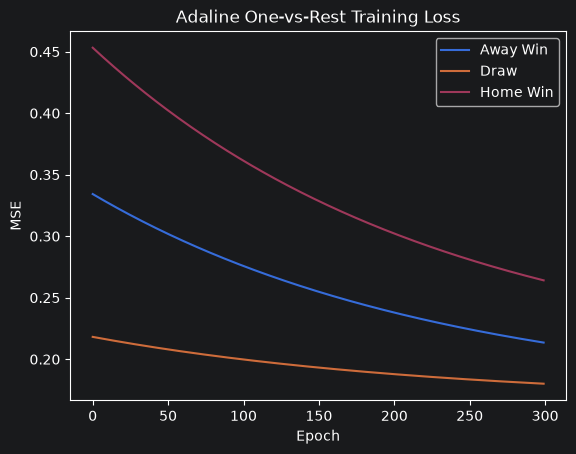

In [21]:
import matplotlib.pyplot as plt
for class_label, model in zip(
    adaline.classes_,
    adaline.models_
):
    plt.plot(
        model.losses_,
        label=class_label
    )

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Adaline One-vs-Rest Training Loss")
plt.legend()
plt.show()

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=123
        )
    ),

    "KNN": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        KNeighborsClassifier(
            n_neighbors=5
        )
    ),

    "Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=123
        )
    )
}

In [23]:
results = [{
    "Model": "Adaline OVR",
    "Accuracy": accuracy_score(
        y_valid,
        ada_pred
    ),
    "Macro F1": f1_score(
        y_valid,
        ada_pred,
        average="macro"
    )

}]

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_valid,
            predictions
        ),
        "Macro F1": f1_score(
            y_valid,
            predictions,
            average="macro"
        )
    })

results_df = pd.DataFrame(results)
results_df.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1
2,KNN,0.585253,0.535936
3,Random Forest,0.566820,0.534923
1,Logistic Regression,0.529954,0.522259
0,Adaline OVR,0.617512,0.452353


To improve accuracy, Now I'll add Recent Form.
The goal is not add current match's:
- Goals
- Shots
- Shotso on Target
- Corners
- Cards
- Xg
Instead, I can calculate the averages from each team's previous five matches, I can also calculate what was the average of the previous five matches average betting odds.

Goals are the safest point since they are consistently available. Shots and related match stats have more missing values.
\
In order to get the stats for previous games, I'll need to create a new DF history with derivate columns such as "points", "goals_for", "goals_against"

In [24]:
from collections import defaultdict

def summarize_team(history, team, window=5):
    recent_matches = history.get(team, [])[-window:]
    if(len(recent_matches)==0):
        return 1,1,1
    points= np.mean([
        match["points"]
        for match in recent_matches
    ])
    #get points, goals_for, goals_against
    goals_for = np.mean([
        match["goals_for"]
        for match in recent_matches
    ])
    goals_against = np.mean([
        match["goals_against"]
        for match in recent_matches
    ])
    return points, goals_for, goals_against

def pre_match_form(matches, window=5):
    matches = matches.sort_values("Date")
    history = defaultdict(list)
    home_form=[]
    away_form=[]
    for row in matches.itertuples():
        home_summary = summarize_team(
            history,
            row.Home,
            window
        )
        away_summary = summarize_team(
            history,
            row.Away,
            window
        )
        home_form.append(home_summary)
        away_form.append(away_summary)

        if row.HGFT > row.AGFT:
            home_points, away_points = 3, 0
        elif row.HGFT < row.AGFT:
            home_points, away_points = 0, 3
        else:
            home_points, away_points = 1, 1

        # Update only after saving the pre-match features
        history[row.Home].append({
            "points": home_points,
            "goals_for": row.HGFT,
            "goals_against": row.AGFT
        })

        history[row.Away].append({
            "points": away_points,
            "goals_for": row.AGFT,
            "goals_against": row.HGFT
        })

    matches[[
        "HomeFormPoints",
        "HomeGoalsFor",
        "HomeGoalsAgainst"
    ]] = home_form

    matches[[
        "AwayFormPoints",
        "AwayGoalsFor",
        "AwayGoalsAgainst"
    ]] = away_form

    matches["FormDifference"] = (
        matches["HomeFormPoints"]
        - matches["AwayFormPoints"]
    )

    return matches, history


In [25]:
dev_df["Date"] = pd.to_datetime(dev_df["Date"])

dev_df, final_team_history = pre_match_form(
    dev_df,
    window=5
)

In [26]:
dev_df.head()

,Date,Home,Away,HGFT,AGFT,H_Max,D_Max,A_Max,H-Avg,D-Avg,...,Pinny-D,Pinny-A,Result,HomeFormPoints,HomeGoalsFor,HomeGoalsAgainst,AwayFormPoints,AwayGoalsFor,AwayGoalsAgainst,FormDifference
1080,2014-06-12,Brazil,Croatia,3,1,NaN,NaN,NaN,1.31,5.11,...,5.16,13.33,Home Win,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1077,2014-06-13,Chile,Australia,3,1,NaN,NaN,NaN,1.42,4.4,...,4.55,9.44,Home Win,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1079,2014-06-13,Mexico,Cameroon,1,0,NaN,NaN,NaN,2.18,3.14,...,3.25,3.82,Home Win,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1078,2014-06-13,Spain,Netherlands,1,5,NaN,NaN,NaN,1.84,3.32,...,3.44,5.31,Away Win,1.0,1.0,1.0,1.0,1.0,1.0,0.0
1074,2014-06-14,England,Italy,1,2,NaN,NaN,NaN,2.51,2.99,...,3.05,3.45,Away Win,1.0,1.0,1.0,1.0,1.0,1.0,0.0


In [27]:
feature_cols = [
    "H-Avg",
    "D-Avg",
    "A-Avg",
    "HomeFormPoints",
    "AwayFormPoints",
    "HomeGoalsFor",
    "AwayGoalsFor",
    "HomeGoalsAgainst",
    "AwayGoalsAgainst"
]

dev_df["HomeGoalDifference"] = (
    dev_df["HomeGoalsFor"]
    - dev_df["HomeGoalsAgainst"]
)

dev_df["AwayGoalDifference"] = (
    dev_df["AwayGoalsFor"]
    - dev_df["AwayGoalsAgainst"]
)

dev_df["RecentGoalDifference"] = (
    dev_df["HomeGoalDifference"]
    - dev_df["AwayGoalDifference"]
)

In [28]:
def add_implied_probabilities(data):
    data = data.copy()

    home_inverse = 1 / pd.to_numeric(
        data["H-Avg"], errors="coerce"
    )
    draw_inverse = 1 / pd.to_numeric(
        data["D-Avg"], errors="coerce"
    )
    away_inverse = 1 / pd.to_numeric(
        data["A-Avg"], errors="coerce"
    )

    probability_total = (
        home_inverse
        + draw_inverse
        + away_inverse
    )

    data["HomeProbability"] = (
        home_inverse / probability_total
    )
    data["DrawProbability"] = (
        draw_inverse / probability_total
    )
    data["AwayProbability"] = (
        away_inverse / probability_total
    )

    return data

def add_wc2026_form(matches, history, window=5):
    matches = matches.copy()

    home_form = [
        summarize_team(history, team, window)
        for team in matches["Home"]
    ]

    away_form = [
        summarize_team(history, team, window)
        for team in matches["Away"]
    ]

    matches[[
        "HomeFormPoints",
        "HomeGoalsFor",
        "HomeGoalsAgainst"
    ]] = home_form

    matches[[
        "AwayFormPoints",
        "AwayGoalsFor",
        "AwayGoalsAgainst"
    ]] = away_form

    matches["FormDifference"] = (
        matches["HomeFormPoints"]
        - matches["AwayFormPoints"]
    )

    return matches

def add_derived_features(data):
    data = add_implied_probabilities(data)

    data["HomeGoalDifference"] = (
        data["HomeGoalsFor"]
        - data["HomeGoalsAgainst"]
    )

    data["AwayGoalDifference"] = (
        data["AwayGoalsFor"]
        - data["AwayGoalsAgainst"]
    )

    data["RecentGoalDifference"] = (
        data["HomeGoalDifference"]
        - data["AwayGoalDifference"]
    )

    return data


In [29]:
test_2026 = add_wc2026_form(
    test_2026,
    final_team_history,
    window=5
)
dev_df = add_derived_features(dev_df)
test_2026 = add_derived_features(test_2026)

After building the new derivative features, I'll define the features in a list and rebuild the datasets

In [30]:
feature_cols = [
    "HomeProbability",
    "DrawProbability",
    "AwayProbability",
    "HomeFormPoints",
    "AwayFormPoints",
    "HomeGoalsFor",
    "AwayGoalsFor",
    "HomeGoalsAgainst",
    "AwayGoalsAgainst",
    "FormDifference",
    "RecentGoalDifference"
]
X=dev_df[feature_cols].apply(pd.to_numeric, errors="coerce")
y=dev_df["Result"]
X_2026= test_2026[feature_cols].apply(pd.to_numeric, errors="coerce")
y_2026= test_2026["Result"]

Now Test the models with the new dataset and train new models

In [31]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)
imr = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imr = imr.fit_transform(X_train)
X_valid_imr = imr.transform(X_valid)
X_2026_imr = imr.transform(X_2026)

X_train_std = scaler.fit_transform(X_train_imr)
X_valid_std = scaler.transform(X_valid_imr)
X_2026_std = scaler.transform(X_2026_imr)

adaline = AdalineOVR(
    n_iter=300, eta=0.001, random_state=123
)
adaline.fit(X_train_std, y_train)
ada_pred = adaline.predict(X_valid_std)
ada_pred_2026 = adaline.predict(X_2026_std)
ada_pred_2026_prob = 0
print(classification_report(
    y_2026,
    ada_pred_2026,
    zero_division=0
))

models = {
    "KNN": make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        KNeighborsClassifier(
            n_neighbors=5
        )
    ),

    "Random Forest": make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=123
        )
    )
}
results = [{"Model": "Adaline",
        "Accuracy": accuracy_score(
            y_2026,
            ada_pred_2026
        ),
        "Macro F1": f1_score(
        y_2026,
        ada_pred_2026,
        average="macro"
        )}]
predictions_2026 = [{"Model": "Adaline",
        "Predictions": ada_pred_2026,
        "Pred_prob": ada_pred_2026_prob}]

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)
    pred_2026 = model.predict(X_2026)
    pred_2026_prob = model.predict_proba(X_2026)
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_valid,
            predictions
        ),
        "Macro F1": f1_score(
            y_valid,
            predictions,
            average="macro"
        )
    })
    predictions_2026.append({
        "Model": model_name,
        "Predictions": pred_2026,
        "Pred_prob": ada_pred_2026_prob
    })


results_df = pd.DataFrame(results)
results_df.sort_values(
    "Macro F1",
    ascending=False
)

              precision    recall  f1-score   support

    Away Win       0.66      0.86      0.75        29
        Draw       0.56      0.19      0.28        27
    Home Win       0.67      0.79      0.72        48

    accuracy                           0.65       104
   macro avg       0.63      0.61      0.58       104
weighted avg       0.64      0.65      0.61       104



,Model,Accuracy,Macro F1
0,Adaline,0.653846,0.582619
2,Random Forest,0.589862,0.531532
1,KNN,0.557604,0.492160


In [32]:
ada_pred_2026

array(['Home Win', 'Draw', 'Away Win', 'Home Win', 'Away Win', 'Home Win',
       'Away Win', 'Away Win', 'Home Win', 'Home Win', 'Draw', 'Away Win',
       'Home Win', 'Home Win', 'Away Win', 'Away Win', 'Home Win',
       'Away Win', 'Home Win', 'Home Win', 'Home Win', 'Home Win',
       'Home Win', 'Away Win', 'Home Win', 'Home Win', 'Home Win',
       'Away Win', 'Home Win', 'Away Win', 'Home Win', 'Home Win',
       'Home Win', 'Home Win', 'Home Win', 'Away Win', 'Home Win',
       'Home Win', 'Home Win', 'Away Win', 'Home Win', 'Home Win', 'Draw',
       'Away Win', 'Home Win', 'Home Win', 'Away Win', 'Home Win',
       'Home Win', 'Home Win', 'Home Win', 'Away Win', 'Away Win',
       'Away Win', 'Away Win', 'Away Win', 'Home Win', 'Away Win', 'Draw',
       'Home Win', 'Away Win', 'Home Win', 'Home Win', 'Away Win', 'Draw',
       'Away Win', 'Home Win', 'Away Win', 'Away Win', 'Home Win', 'Draw',
       'Away Win', 'Home Win', 'Home Win', 'Home Win', 'Draw', 'Away Win',
      

In [33]:
results = []
prediction_tables = {}

def record_results(
    model_name,
    valid_predictions,
    test_predictions
):
    results.append({
        "Model": model_name,
        "Validation Accuracy": accuracy_score(
            y_valid,
            valid_predictions
        ),
        "Validation Macro F1": f1_score(
            y_valid,
            valid_predictions,
            average="macro"
        ),
        "2026 Accuracy": accuracy_score(
            y_2026,
            test_predictions
        ),
        "2026 Macro F1": f1_score(
            y_2026,
            test_predictions,
            average="macro"
        )
    })

    table = test_2026[
        ["Home", "Away", "HGFT", "AGFT"]
    ].copy()

    table["Actual"] = y_2026
    table["Prediction"] = test_predictions
    table["Correct"] = (
        table["Actual"] == table["Prediction"]
    )

    prediction_tables[model_name] = table


# Adaline was trained separately
record_results(
    "Adaline",
    ada_pred,
    ada_pred_2026
)

# Train and evaluate scikit-learn models
for model_name, model in models.items():
    model.fit(X_train, y_train)

    valid_predictions = model.predict(X_valid)
    test_predictions = model.predict(X_2026)

    record_results(
        model_name,
        valid_predictions,
        test_predictions
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    "Validation Macro F1",
    ascending=False
)

for model_name, table in prediction_tables.items():
    print(f"\n{model_name} predictions:")
    show_table(table.head(20))


Adaline predictions:


,Home,Away,HGFT,AGFT,Actual,Prediction,Correct
0,Mexico,South Africa,2,0,Home Win,Home Win,True
1,South Korea,Czech Republic,2,1,Home Win,Draw,False
2,Canada,Bosnia & Herzegovina,1,1,Draw,Away Win,False
3,USA,Paraguay,4,1,Home Win,Home Win,True
4,Qatar,Switzerland,1,1,Draw,Away Win,False
5,Brazil,Morocco,1,1,Draw,Home Win,False
6,Haiti,Scotland,0,1,Away Win,Away Win,True
7,Australia,Turkey,2,0,Home Win,Away Win,False
8,Germany,Curacao,7,1,Home Win,Home Win,True
9,Netherlands,Japan,2,2,Draw,Home Win,False



KNN predictions:


,Home,Away,HGFT,AGFT,Actual,Prediction,Correct
0,Mexico,South Africa,2,0,Home Win,Home Win,True
1,South Korea,Czech Republic,2,1,Home Win,Home Win,True
2,Canada,Bosnia & Herzegovina,1,1,Draw,Home Win,False
3,USA,Paraguay,4,1,Home Win,Away Win,False
4,Qatar,Switzerland,1,1,Draw,Away Win,False
5,Brazil,Morocco,1,1,Draw,Home Win,False
6,Haiti,Scotland,0,1,Away Win,Away Win,True
7,Australia,Turkey,2,0,Home Win,Away Win,False
8,Germany,Curacao,7,1,Home Win,Home Win,True
9,Netherlands,Japan,2,2,Draw,Home Win,False



Random Forest predictions:


,Home,Away,HGFT,AGFT,Actual,Prediction,Correct
0,Mexico,South Africa,2,0,Home Win,Home Win,True
1,South Korea,Czech Republic,2,1,Home Win,Away Win,False
2,Canada,Bosnia & Herzegovina,1,1,Draw,Home Win,False
3,USA,Paraguay,4,1,Home Win,Draw,False
4,Qatar,Switzerland,1,1,Draw,Away Win,False
5,Brazil,Morocco,1,1,Draw,Home Win,False
6,Haiti,Scotland,0,1,Away Win,Away Win,True
7,Australia,Turkey,2,0,Home Win,Away Win,False
8,Germany,Curacao,7,1,Home Win,Home Win,True
9,Netherlands,Japan,2,2,Draw,Draw,True


In [34]:
prediction_tables["Adaline"]

,Home,Away,HGFT,AGFT,Actual,Prediction,Correct
0,Mexico,South Africa,2,0,Home Win,Home Win,True
1,South Korea,Czech Republic,2,1,Home Win,Draw,False
2,Canada,Bosnia & Herzegovina,1,1,Draw,Away Win,False
3,USA,Paraguay,4,1,Home Win,Home Win,True
4,Qatar,Switzerland,1,1,Draw,Away Win,False
...,...,...,...,...,...,...,...
99,Argentina,Switzerland,1,1,Draw,Home Win,False
100,France,Spain,0,2,Away Win,Away Win,True
101,England,Argentina,1,2,Away Win,Draw,False
102,France,England,4,6,Away Win,Home Win,False
